# **run_SpatialEx：基于 H&E 病理图像的单细胞分辨率空间组学翻译**

本脚本基于 SpatialEx 模型，使用 Xenium Human Breast Cancer 两个切片（Rep1 / Rep2）演示如何从 H&E 病理图像直接预测细胞级别的基因表达。

## 0. SpatialEx 算法逻辑梳理

SpatialEx 的核心目标：**仅利用 H&E 病理图像，预测每个细胞的空间转录组表达**，从而把昂贵的空间转录组（ST）信息扩展到任意只有 H&E 的区域。

### 0.1 输入数据
1. **配对的 ST + H&E 切片**（本例 Rep1、Rep2）：
   - Xenium 单细胞表达矩阵 `cell_feature_matrix.h5` 与 `cells.csv`（细胞坐标）
   - 对齐后的 H&E 全片图像 `*.ome.tif` 与配准矩阵 `*_imagealignment.csv`
2. **测序区域之外的 H&E 病理图像**：通过细胞分割得到坐标 `HBRC_RepX_cell_coor.csv` 与对应的 patch 嵌入 `HBRC_RepX_Out_uni.npy`

### 0.2 数据预处理流程
1. `Read_Xenium`：读入 Xenium 表达矩阵和细胞坐标，构造 AnnData。
2. `Preprocess_adata`：QC、归一化、log 变换。
3. `Read_HE_image` + `Register_physical_to_pixel`：把物理坐标对齐到 H&E 图像像素坐标。
4. `Tiling_HE_patches`：以每个细胞为中心，按 `resolution` 切出 H&E patch（半径 = resolution/2）。
5. `Extract_HE_patches_representaion`：使用病理基础模型（默认 UNI，可选 CONCH/Gigapath/Phikon/ResNet50）把每个 patch 编码为高维表征，存入 `adata.obsm['he']`。

### 0.3 图结构
- `Build_hypergraph_spatial_and_HE`：基于细胞空间坐标的 KNN 构造 **超图（hypergraph）**，作为后续 HGNN 的连接结构（`graph_kind='spatial'`，邻居数 `num_neighbors=7`）。
- 测序区域之外的细胞用 `Build_hypergraph` 直接基于像素坐标构图。

### 0.4 模型与训练
- 主干网络：**HGNN**（Hypergraph Neural Network）。每个切片各有一个独立模型：
   - `module_HA`：切片 1 的 H&E → Panel A（切片 1 基因表达）回归头
   - `module_HB`：切片 2 的 H&E → Panel B（切片 2 基因表达）回归头
- 损失：MSE，对真实表达进行回归（默认在 spot 聚合分辨率上计算损失）。
- 训练时两个模型联合更新（梯度同时反传），使两个 H&E 表征空间对齐到同一类基因表达上下文。

### 0.5 跨切片推断与扩展（核心“翻译”能力）
- **测序区域之内**：用切片 2 的训练模型 `module_HB` 预测切片 1 上每个细胞的 Panel B 表达 → `panelB1`；同理用切片 1 模型预测切片 2 → `panelA2`。
- **测序区域之外**：拿外部 H&E patch 的嵌入 + 重新构建的空间超图，直接走对应模型，得到 `panelA1_out / panelB1_out / panelA2_out / panelB2_out`，实现 H&E 病理图像到 ST 的“无 ST 标签”推断。

### 0.6 评估指标
- **PCC**（皮尔逊相关）：每个基因预测值与真实值的相关性，衡量幅度+趋势一致性。
- **SSIM**（基于空间图）：在空间邻域上度量结构相似度，衡量空间模式保留情况。
- **CMD**（Co-expression Matrix Distance）：度量基因-基因协表达模式的偏差。

下面的代码完整地复现了上述流程，并在评估阶段额外加入了**指标可视化**（每基因 PCC / SSIM / CMD 的分布、Top 基因排序、PCC 与 SSIM 的散点关系等）。

In [1]:

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import SpatialEx as se

# 训练设备
device = 'cuda:0'

# 数据根目录与每个切片子目录
data_root = '/data1/linxin/1/SpatialEx/data/raw_data/HBC/'
save_root1 = data_root + 'Human_Breast_Cancer_Rep1/'
save_root2 = data_root + 'Human_Breast_Cancer_Rep2/'
resolution = 64
image_encoder = 'uni'

## 1. 数据准备（从原始数据预处理）

数据目录约定如下（与本脚本路径一致）：
```
/data1/linxin/1/SpatialEx/data/raw_data/HBC/
├── Human_Breast_Cancer_Rep1/
│   ├── cell_feature_matrix.h5
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv
│   ├── HBRC_Rep1_cell_coor.csv
│   └── HBRC_Rep1_Out_uni.npy
├── Human_Breast_Cancer_Rep2/
│   ├── cell_feature_matrix.h5
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv
│   ├── HBRC_Rep2_cell_coor.csv
│   └── HBRC_Rep2_Out_uni.npy
└── Selection_by_name.csv
```

In [2]:
pass

### 1.1 预处理切片 1 & 2（首次跑完会保存缓存，以后秒读）

首次运行需要 Tiling + UNI 编码（约 15-30 分钟/切片），完成后会把带 `obsm['he']` 的 adata 保存为 `.h5ad` 文件。  
**后续运行只读缓存文件，跳过 UNI 编码。**

In [3]:
import os

cache_path1 = save_root1 + f'adata_preprocessed_{image_encoder}_res{resolution}.h5ad'
cache_path2 = save_root2 + f'adata_preprocessed_{image_encoder}_res{resolution}.h5ad'

# ========== 切片 1 ==========
if os.path.exists(cache_path1):
    print(f'[Rep1] 直接读取缓存: {cache_path1}')
    adata1 = sc.read_h5ad(cache_path1)
else:
    print('[Rep1] 首次运行，开始预处理 + UNI 编码...')
    file_path1          = save_root1 + 'cell_feature_matrix.h5'
    obs_path1           = save_root1 + 'cells.csv'
    img_path1           = save_root1 + 'Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif'
    transform_mtx_path1 = save_root1 + 'Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv'

    adata1 = se.pp.Read_Xenium(file_path1, obs_path1)
    adata1 = se.pp.Preprocess_adata(adata1)

    img, scale     = se.pp.Read_HE_image(img_path1)
    transform_mtx  = pd.read_csv(transform_mtx_path1, header=None).values
    adata1         = se.pp.Register_physical_to_pixel(adata1, transform_mtx, scale=scale)

    he_patches, adata1 = se.pp.Tiling_HE_patches(resolution, adata1, img)
    adata1 = se.pp.Extract_HE_patches_representaion(
        he_patches, adata=adata1, image_encoder=image_encoder, device=device, store_key='he'
    )
    adata1.write_h5ad(cache_path1)
    print(f'[Rep1] 缓存已保存: {cache_path1}')

# ========== 切片 2 ==========
if os.path.exists(cache_path2):
    print(f'[Rep2] 直接读取缓存: {cache_path2}')
    adata2 = sc.read_h5ad(cache_path2)
else:
    print('[Rep2] 首次运行，开始预处理 + UNI 编码...')
    file_path2          = save_root2 + 'cell_feature_matrix.h5'
    obs_path2           = save_root2 + 'cells.csv'
    img_path2           = save_root2 + 'Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif'
    transform_mtx_path2 = save_root2 + 'Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv'

    adata2 = se.pp.Read_Xenium(file_path2, obs_path2)
    adata2 = se.pp.Preprocess_adata(adata2)

    img, scale     = se.pp.Read_HE_image(img_path2)
    transform_mtx  = pd.read_csv(transform_mtx_path2, header=None).values
    adata2         = se.pp.Register_physical_to_pixel(adata2, transform_mtx, scale=scale)

    he_patches, adata2 = se.pp.Tiling_HE_patches(resolution, adata2, img)
    adata2 = se.pp.Extract_HE_patches_representaion(
        he_patches, adata=adata2, image_encoder=image_encoder, store_key='he', device=device
    )
    adata2.write_h5ad(cache_path2)
    print(f'[Rep2] 缓存已保存: {cache_path2}')

print(f'\nadata1: {adata1.shape}, he={adata1.obsm["he"].shape}')
print(f'adata2: {adata2.shape}, he={adata2.obsm["he"].shape}')

[Rep1] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep1/adata_preprocessed_uni_res64.h5ad
[Rep2] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep2/adata_preprocessed_uni_res64.h5ad

adata1: (164000, 313), he=(164000, 1024)
adata2: (111555, 313), he=(111555, 1024)


## 2. 训练 SpatialEx

### 2.1 在测序区域内训练并互相预测

In [4]:
# 超图近邻数 与 训练轮数
num_neighbors = 7
epochs        = 500

# 基于空间 KNN 构造超图
graph1 = se.pp.Build_hypergraph_spatial_and_HE(adata1, num_neighbors, graph_kind='spatial', return_type='crs')
graph2 = se.pp.Build_hypergraph_spatial_and_HE(adata2, num_neighbors, graph_kind='spatial', return_type='crs')

# 训练 SpatialEx：联合优化两个切片的 HGNN 模型
spatialex = se.SpatialEx(adata1, adata2, graph1, graph2, epochs=epochs, device=device)
spatialex.train()

# 跨切片预测：用切片 2 的模型预测切片 1，反之亦然
panelB1, panelA2 = spatialex.auto_inference()

164000  cells are included in its nearest spot!
111555  cells are included in its nearest spot!


=================================== Start training =========================================


#Epoch: 499: train_loss: 11.24: 100%|██████████| 500/500 [05:27<00:00,  1.52it/s]


### 2.2 推断到测序区域之外（仅用 H&E 病理图）

In [5]:
# 读入测序区外的细胞坐标 + 对应 H&E patch 嵌入
# make_hbrc_out_uni.py（padding 版）对所有细胞提取 embedding，行数与 cell_coor.csv 一致
out_spatial1 = pd.read_csv(save_root1 + 'HBRC_Rep1_cell_coor.csv', index_col=0)
out_spatial2 = pd.read_csv(save_root2 + 'HBRC_Rep2_cell_coor.csv', index_col=0)
out_he1      = np.load(save_root1 + 'HBRC_Rep1_Out_uni.npy')
out_he2      = np.load(save_root2 + 'HBRC_Rep2_Out_uni.npy')
assert out_spatial1.shape[0] == out_he1.shape[0], (out_spatial1.shape[0], out_he1.shape[0])
assert out_spatial2.shape[0] == out_he2.shape[0], (out_spatial2.shape[0], out_he2.shape[0])

# 基于像素坐标重新构图
graph1 = se.pp.Build_hypergraph(out_spatial1.values, num_neighbors=num_neighbors, normalize=True)
graph2 = se.pp.Build_hypergraph(out_spatial2.values, num_neighbors=num_neighbors, normalize=True)

# 走训练好的两个模型完成区外推断
panelA1_out = spatialex.inference(out_he1, graph1, panel='panelA')
panelA2_out = spatialex.inference(out_he2, graph2, panel='panelA')
panelB1_out = spatialex.inference(out_he1, graph1, panel='panelB')
panelB2_out = spatialex.inference(out_he2, graph2, panel='panelB')

## 3. 评估

### 3.1 定量指标 + 可视化

下面为每一组（Slice1→Slice2, Slice2→Slice1）计算每基因的 PCC / SSIM / CMD，并绘制：
1. 三个指标的箱线/直方分布


In [6]:
# 通用：把每基因指标绘制为分布 + Top-N 条形图
def plot_metric_distribution(pcc, ssim, cmd, var_names, title_prefix='Slice'):
    """
    pcc / ssim / cmd 均为长度等于基因数的一维数组。
    var_names 为对应的基因名序列。
    """
    pcc  = np.asarray(pcc).ravel()
    ssim = np.asarray(ssim).ravel()
    cmd  = np.asarray(cmd).ravel() if np.ndim(cmd) > 0 and np.size(cmd) > 1 else np.full_like(pcc, float(np.asarray(cmd).mean()))

    df = pd.DataFrame({'gene': list(var_names), 'PCC': pcc, 'SSIM': ssim, 'CMD': cmd})

    cmd_scalar = float(np.asarray(cmd).mean())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.histplot(df['PCC'],  kde=True, ax=axes[0], color='#2E86AB'); axes[0].set_title(f'{title_prefix} - PCC 分布')
    sns.histplot(df['SSIM'], kde=True, ax=axes[1], color='#A23B72'); axes[1].set_title(f'{title_prefix} - SSIM 分布')
    axes[2].text(0.5, 0.5, f'CMD\n{cmd_scalar:.4f}', ha='center', va='center',
                 fontsize=24, color='#F18F01', transform=axes[2].transAxes)
    axes[2].set_title(f'{title_prefix} - CMD（矩阵级标量）')
    axes[2].axis('off')
    plt.tight_layout(); plt.show(); plt.close(fig)

    return df

#### 3.1.1 在 Slice1 上训练，预测 Slice2（即评估 panelB1 与 Slice1 真值的相符程度）

x shape is  164000
cell number is less than 200000
Slice1 上预测的基因表达评估，PCC:  0.25610077  SSIM:  0.36652292309273266  CMD:  0.20377531448619524


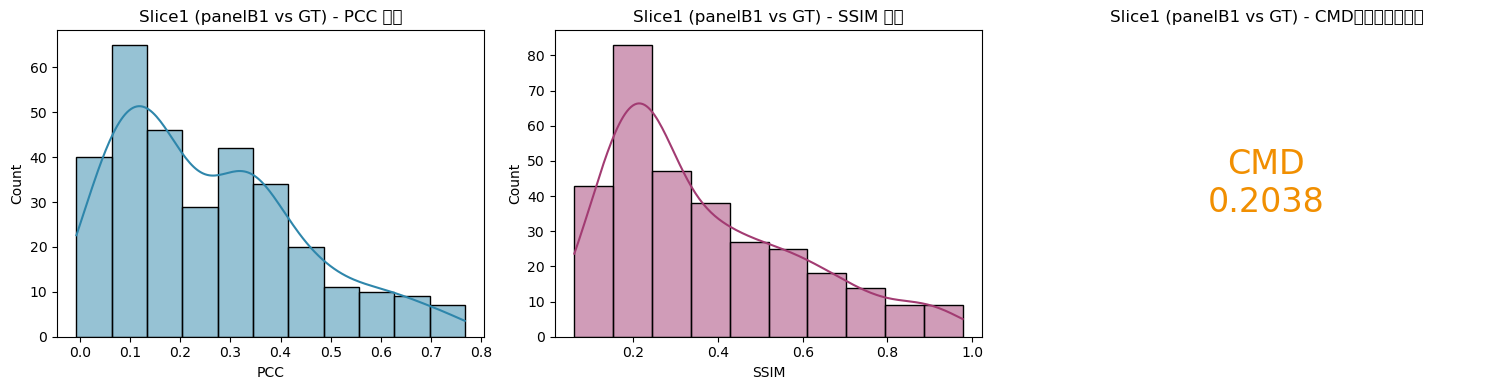

In [7]:
# 基于 Slice1 的空间坐标构造评估用图（高斯加权 KNN）
graph = se.pp.Build_graph(adata1.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')

# 计算每个基因的 SSIM / PCC / CMD
ssim, ssim_reduce = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='ssim', graph=graph, reduce='mean')
pcc,  pcc_reduce  = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='pcc',                  reduce='mean')
cmd,  cmd_reduce  = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='cmd',                  reduce='mean')
print('Slice1 上预测的基因表达评估，PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

# 可视化指标分布
_ = plot_metric_distribution(pcc, ssim, cmd, var_names=adata1.var_names, title_prefix='Slice1 (panelB1 vs GT)')

#### 3.1.2 在 Slice2 上训练，预测 Slice1（即评估 panelA2 与 Slice2 真值的相符程度）

x shape is  111555
cell number is less than 200000
Slice2 上预测的基因表达评估，PCC:  0.27661327  SSIM:  0.3833826747541293  CMD:  0.2057154728666868


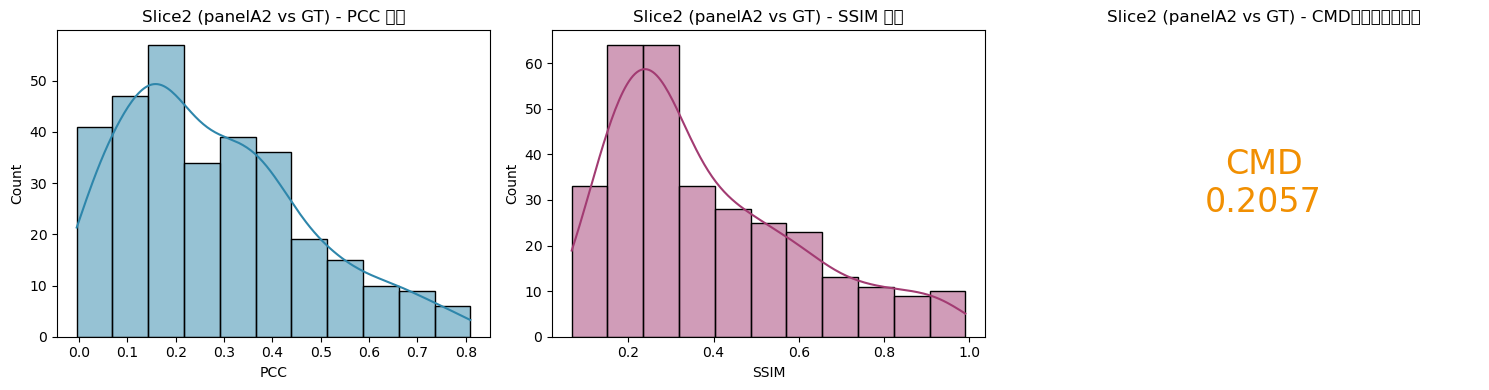

In [8]:
graph = se.pp.Build_graph(adata2.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')

ssim, ssim_reduce = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='ssim', graph=graph)
pcc,  pcc_reduce  = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='pcc',  reduce='mean')
cmd,  cmd_reduce  = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='cmd',  reduce='mean')
print('Slice2 上预测的基因表达评估，PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

_ = plot_metric_distribution(pcc, ssim, cmd, var_names=adata2.var_names, title_prefix='Slice2 (panelA2 vs GT)')

### 3.2 空间表达可视化

#### 3.2.1 Slice1→Slice2：在测序区内 + 区外联合可视化

In [14]:
# 测序区域边界
# image_coor[:, 0] = row（图像行/纵坐标），image_coor[:, 1] = col（图像列/横坐标）
col_min = adata2.obsm['image_coor'][:, 1].min()
col_max = adata2.obsm['image_coor'][:, 1].max()
row_min = adata2.obsm['image_coor'][:, 0].min()
row_max = adata2.obsm['image_coor'][:, 0].max()

# 区外细胞中落入测序区范围内的要排除（否则会和区内点重叠）
out_row = out_spatial2['image_row'].values
out_col = out_spatial2['image_col'].values
selection = ((out_row > row_min) & (out_row < row_max) &
             (out_col > col_min) & (out_col < col_max))

# 通用绘图函数：区内 + 区外 + 红框 + PCC（坐标映射与 Tutorial 1 完全一致）
def plot_gene_spatial(gene_name, adata_inner, pred_inner, pred_outer):
    gene_idx = np.where(adata_inner.var_names == gene_name)[0]
    if len(gene_idx) == 0:
        print(f'{gene_name} 不在 var_names 中'); return
    gene_idx = gene_idx[0]

    val_in = np.asarray(pred_inner[:, gene_idx]).ravel()
    vmax = val_in.max()

    fig, ax = plt.subplots(figsize=(7, 7))
    # 区内散点：x 轴 = row，y 轴 = col
    ax.scatter(adata_inner.obsm['image_coor'][:, 0],
               adata_inner.obsm['image_coor'][:, 1],
               c=val_in, vmin=0, vmax=vmax, s=0.01, cmap='viridis')

    # 红色虚线标注测序区域（row 在 x 轴，col 在 y 轴）
    ax.plot([row_min, row_min, row_max, row_max, row_min],
            [col_min, col_max, col_max, col_min, col_min],
            color='red', linestyle='--')

    # 区外散点：image_row → x 轴，image_col → y 轴（与区内一致）
    val_out = np.asarray(pred_outer[:, gene_idx]).ravel()
    ax.scatter(out_row[~selection], out_col[~selection],
               c=val_out[~selection], s=0.01, vmin=0, vmax=vmax, cmap='viridis')

    # 坐标范围设为整张 H&E 图像大小
    ax.set_xlim(0, out_row.max())
    ax.set_ylim(0, out_col.max())

    title = gene_name
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

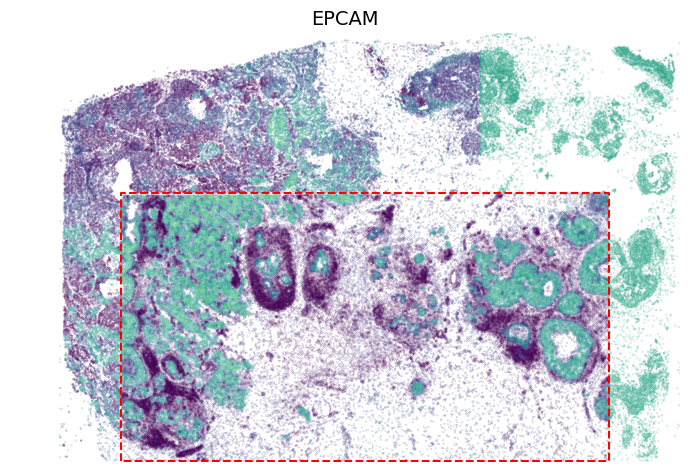

In [15]:

plot_gene_spatial('EPCAM', adata2, panelA2, panelA2_out)

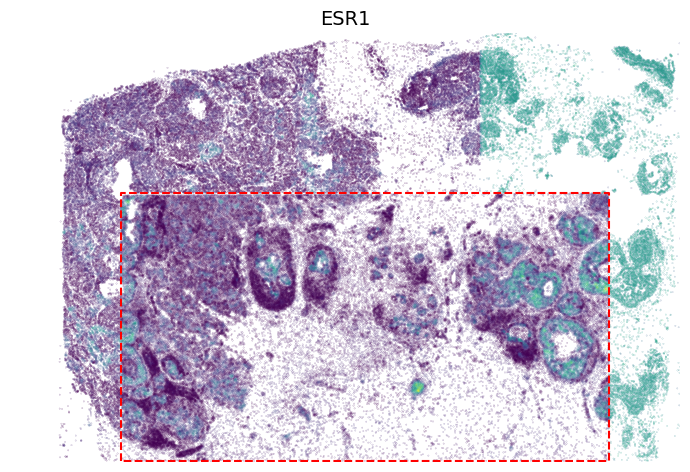

In [16]:
plot_gene_spatial('ESR1', adata2, panelA2, panelA2_out)

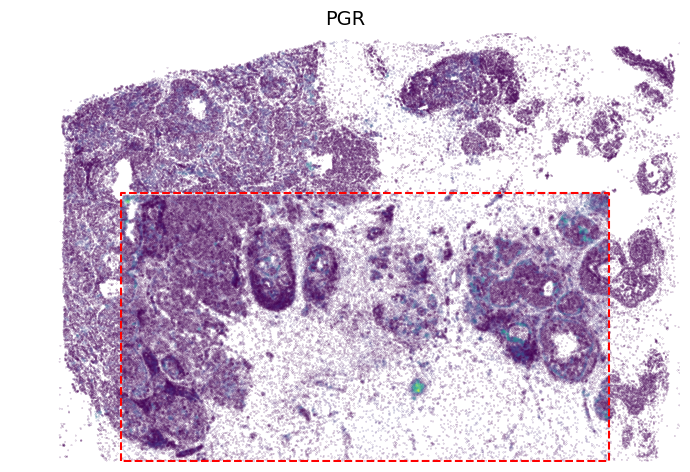

In [17]:
plot_gene_spatial('PGR', adata2, panelA2, panelA2_out)